In [1]:
#Dependencies

import nd2

import numpy as np
import math
import pandas as pd
import seaborn as sns
sns.set_theme(style='white', font_scale = 2)

import matplotlib.pyplot as plt
from matplotlib.colors import SymLogNorm
import matplotlib

from scipy import ndimage as ndi
from scipy.ndimage import distance_transform_edt, binary_erosion, binary_dilation, binary_fill_holes, generate_binary_structure
import scipy.ndimage.filters as filters
from scipy import fftpack
from scipy.signal import savgol_filter
from scipy.interpolate import splev, splprep
from scipy.optimize import curve_fit


from skimage.registration import phase_cross_correlation
import skimage.filters as skf
from skimage.measure import regionprops
from skimage.segmentation import watershed
from skimage.draw import circle_perimeter
#from skimage.morphology import binary_erosion, disk
from skimage.segmentation import clear_border
# this suppresses warnings, not a great idea.
import warnings
warnings.filterwarnings('ignore')

import os


def find_maxima(image,size,threshold_method = "threshold_mean"):
    """
    Locates all local maxima in an image. 
    
    :param image: 2-dimensional image array.
    :param size: int, size of the maxima and minimum filters used
    :param threshold_method: string, type of thresholding filter
        used. Accepts any threshold_filter in the ``skimmage.filters``
        module.
        Default is threshold_mean

    :return: 1D array of [(x,y),...] defining the locations of each
        maximum
    """
    im_max = filters.maximum_filter(image, size)
    im_min = filters.minimum_filter(image, size)
    im_diff = im_max - im_min

    maxima=(image==im_max)
    thresh = getattr(skf, threshold_method)(im_diff)
    bool_diff = (im_diff < thresh)
    maxima[bool_diff] = False

    labeled, num_objects = ndi.label(maxima)
    slices = ndi.find_objects(labeled)
    points = []
    for dy,dx in slices:
        points.append((dx.start,dy.start)) 
    return points



def Segment_droplets(Image_List, pixel_size, Watershed = True, thresh_area = 10):

    grouped_mask = np.zeros_like(Image_List[0], dtype=bool)
    for image in Image_List:    
        thresh = skf.threshold_otsu(image)
        im_binary = image > thresh
        grouped_mask = np.logical_or(grouped_mask, im_binary)

    labels, _ = ndi.label(grouped_mask)   
    fg_mask = np.zeros_like(labels)
    size_r = Image_List[0].shape[0]
    size_c = Image_List[0].shape[1]
    for j in regionprops(labels):
        area = j.area*(pixel_size**2)    
        if j.area>thresh_area:
            for y,x in j.coords:
                fg_mask[y,x] = 1
    fg_mask = np.array(fg_mask, dtype = bool)
    bg_mask = np.invert(fg_mask)
    
    if Watershed == True:
        distance = distance_transform_edt(fg_mask)
        maxima = np.zeros_like(distance)        
        for x,y in find_maxima(distance, 9, threshold_method = "threshold_mean"):
            maxima[y,x] = 1
        labels, _ = ndi.label(maxima) 
        labels_ws = watershed(-distance, labels, mask=fg_mask, 
                              watershed_line=True)

        filtered_fg_mask = np.zeros_like(labels_ws)
        for z in regionprops(labels_ws):  
            if 1 in z.coords or size_r-2 in z.coords or size_c-2 in z.coords:
                pass
            else:
                if z.eccentricity <= 0.9:
                    for y,x in z.coords:
                        filtered_fg_mask[y,x] = 1
                      
    else:
        labels, _ = ndi.label(fg_mask)
        filtered_fg_mask = np.zeros_like(fg_mask)
        for z in regionprops(labels):  
            if 1 in z.coords or size_r-2 in z.coords or size_c-2 in z.coords:
                pass
            else:
                for y,x in z.coords:
                    filtered_fg_mask[y,x] = 1
        
    labels, _ = ndi.label(filtered_fg_mask) 
    return(labels, fg_mask)

## Read images--need to exclude aggergates

In [2]:
def compute_lowest_z_means3(channel_1, labels, labels_bg, dx, min_bg_pixels=1, verbose=True):
    """
    For each droplet label, find the lowest background-corrected signal across Z
    and return a DataFrame of per-label minima plus the mean of those minima.

    Parameters
    - channel_1: ndarray (Z, Y, X) measurement stack.
    - labels: ndarray (Y, X) or (Z, Y, X) labeled condensates (0 = background).
    - labels_bg: ndarray (Y, X) or (Z, Y, X) boolean or labeled background mask.
    - dx: pixel size in microns.
    - min_bg_pixels: ignore bg mean for a slice if fewer than this many bg pixels present.
    - verbose: if True, print per-z values.

    Returns
    - df_min: pandas.DataFrame with columns ['label','lowest_bg_corrected','z_of_lowest',
               'inside_mean_at_lowest','bg_mean_at_lowest']
    - mean_lowest: float, mean of `lowest_bg_corrected` across labels (nan if none)
    """
    if channel_1.ndim != 3:
        raise ValueError("channel_1 must be (Z, Y, X)")

    Z, Y, X = channel_1.shape

    # Only 2D labels/bg are supported (per-user request)
    if labels.ndim != 2:
        raise ValueError("labels must be 2D (y,x) labeled mask")
    if labels_bg is None:
        raise ValueError("labels_bg must be provided as a 2D background mask")
    if labels_bg.ndim != 2:
        raise ValueError("labels_bg must be 2D (y,x) background mask")

    # Precompute background means per z once (fast) — outside the region loop
    bg_mask2d = labels_bg > 0
    bg_count = int(np.count_nonzero(bg_mask2d))
    
    bg_mean_per_z = np.full(Z, np.nan, dtype=float)
    if bg_count >= min_bg_pixels:
        for z in range(Z):
            bg_vals = channel_1[z][bg_mask2d]
            if bg_vals.size >= min_bg_pixels:
                bg_mean_per_z[z] = float(np.nanmean(bg_vals))

    rows = []
    # For each 2D label, compute inside means across Z using advanced indexing -> vectorized along Z
    for region in regionprops(labels):
                if region.area*(dx**2)> 1: # only consider droplets larger than 1 micron^2
                    lab = int(region.label)
                    coords = region.coords  # (N,2) y,x
                    if coords.size == 0:
                        continue
                    ys = coords[:, 0]
                    xs = coords[:, 1]

                    # channel_1[:, ys, xs] -> shape (Z, N)
                    vals = channel_1[:, ys, xs]
                    # compute mean per z across droplet pixels
                    # if droplet has only one pixel, vals shape is (Z,) or (Z,N); ensure 2D
                    if vals.ndim == 1:
                        inside_mean_per_z = vals.astype(float)
                    else:
                        inside_mean_per_z = np.nanmean(vals, axis=1)

                    # compute ratio per z; where bg_mean_per_z is nan or zero, result will be nan
                    with np.errstate(invalid='ignore', divide='ignore'):
                        ratios = inside_mean_per_z / bg_mean_per_z

                    # mask invalid where bg_mean_per_z is nan
                    valid_mask = ~np.isnan(ratios)
                    if not np.any(valid_mask):
                        lowest_ratio = np.nan
                        lowest_z = None
                        inside_at_lowest = np.nan
                        bg_at_lowest = np.nan
                    else:
                        # argmin over valid entries
                        try:
                            z_idx = int(np.nanargmin(ratios))
                            lowest_ratio = float(ratios[z_idx])
                            lowest_z = int(z_idx)
                            inside_at_lowest = float(inside_mean_per_z[z_idx])
                            bg_at_lowest = float(bg_mean_per_z[z_idx])
                        except ValueError:
                            lowest_ratio = np.nan
                            lowest_z = None
                            inside_at_lowest = np.nan
                            bg_at_lowest = np.nan

                    if verbose:
                        print(f'label={lab}: lowest_ratio={lowest_ratio} at z={lowest_z}')

                    rows.append({
                        'label': int(lab),
                        'lowest_bg_corrected': lowest_ratio,
                        'z_of_lowest': lowest_z,
                        'inside_mean_at_lowest': inside_at_lowest,
                        'bg_mean_at_lowest': bg_at_lowest,
                })

    df_min = pd.DataFrame(rows, columns=['label','lowest_bg_corrected','z_of_lowest','inside_mean_at_lowest','bg_mean_at_lowest'])
    mean_lowest = float(np.nanmean(df_min['lowest_bg_corrected'])) if not df_min.empty else np.nan
    return df_min, mean_lowest

if __name__ == '__main__':
    # small usage example (won't run without real data)
    print('Module saved: compute_lowest_z_means2(channel_1, labels, labels_bg)')


Module saved: compute_lowest_z_means2(channel_1, labels, labels_bg)


In [9]:
def compute_lowest_z_means(channel_1, labels, labels_bg, min_bg_pixels=1):
    """
    Compute per-label, per-z inside and background means from a Z-stack.

    Parameters
    - channel_1: ndarray (Z, Y, X) measurement stack.
    - labels: ndarray (Y, X) OR (Z, Y, X) labeled condensates (0 = background).
    - labels_bg: optional ndarray (Y, X) OR (Z, Y, X) boolean or labeled background mask.
                 If None and use_shell=True, a 2D dilated shell is used per-slice.
    - min_bg_pixels: ignore bg mean if fewer than this many bg pixels present.

    Returns
    - df: pandas.DataFrame with rows for each (label, z) and columns:
      ['label','z','inside_mean','inside_count','bg_mean','bg_count','bg_corrected']
    """
    if channel_1.ndim != 3:
        raise ValueError("channel_1 must be (Z, Y, X)")

    Z, Y, X = channel_1.shape

    rows = []

    # 2D labels: apply same (y,x) footprint across all z
    # for region in regionprops(labels):
    #     lab = int(region.label)
    #     coords = region.coords  # (N,2) y,x
    #     if coords.size == 0:
    #         continue
    #     mask_base = np.zeros((Y, X), dtype=bool)
    #     mask_base[coords[:, 0], coords[:, 1]] = True
    for region in regionprops(labels):
        lab = int(region.label)
        coords = region.coords  # (N,2) y,x
        if coords.size == 0:
            continue
        mask_base = np.zeros((Y, X), dtype=bool)
        mask_base[coords[:, 0], coords[:, 1]] = True

        for z in range(Z):
            inside_vals = channel_1[z][labels]
            inside_count = int(inside_vals.size)
            inside_mean = float(np.nan) if inside_count == 0 else float(np.mean(inside_vals))

            # background mean for this z
            bg_mask2d = (labels_bg > 0) if labels_bg.dtype != bool else labels_bg
            bg_vals = channel_1[z][bg_mask2d]

            bg_count = int(bg_vals.size)
            bg_mean = float(np.nan) if bg_count < min_bg_pixels else float(np.mean(bg_vals))

            bg_corr = np.nan if (np.isnan(inside_mean) or np.isnan(bg_mean)) else float(inside_mean / bg_mean)
            print('background', bg_mean, 'inside', inside_mean, 'corrected', bg_corr)
            rows.append({
                "label": labels,
                "z": int(z),
                "inside_mean": inside_mean,
                "inside_count": inside_count,
                "bg_mean": bg_mean,
                "bg_count": bg_count,
                "bg_corrected": bg_corr,
            })

    lowest_value = np.min([row["bg_corrected"] for row in rows if not np.isnan(row["bg_corrected"])])
    # df = pd.DataFrame(rows, columns=["label","z","inside_mean","inside_count","bg_mean","bg_count","bg_corrected"])
    return lowest_value

# Example usage:
# img = nd2.imread(file_path)            # (Z, C, Y, X)
# channel_0 = img[:, 0, :, :]            # (Z, Y, X)
# # if you have 2D labels (labels, labels_bg) from max-projection segmentation:
# df_per_z = compute_per_z_means(channel_0, labels, labels_bg=labels_bg, use_shell=False)
# # If labels are 3D (from 3D segmentation):
# df_per_z = compute_per_z_means(channel_0, labels_3d, labels_bg=labels_bg_3d)
# # Inspect:
# print(df_per_z.head())

def compute_lowest_z_means2(channel_1, labels, labels_bg, min_bg_pixels=1, verbose=False):
     """
     Compute per-label, per-z inside and background means from a Z-stack.
    Optimized to only process z-slices where label exists and track minimum on-the-fly.
 
     Parameters
     - channel_1: ndarray (Z, Y, X) measurement stack.
    - labels: ndarray (Y, X) labeled condensates (0 = background).
    - labels_bg: ndarray (Y, X) boolean or labeled background mask.
     - min_bg_pixels: ignore bg mean if fewer than this many bg pixels present.
    - verbose: if True, print per-z values (slower).
 
     Returns
    - lowest_value: float, minimum background-corrected ratio across all z-slices.
     """
     if channel_1.ndim != 3:
        raise ValueError("channel_1 must be (Z, Y, X)")

     Z, Y, X = channel_1.shape
     lowest_value = np.inf
     bg_mask_bool = (labels_bg > 0) if labels_bg.dtype != bool else labels_bg
    
    # Find z-indices where label exists (non-zero pixels in labels mask)
     inside_mask = labels > 0
     z_has_label = np.any(inside_mask, axis=(0, 1))  # (Z,) bool array
     z_indices = np.where(z_has_label)[0]
    
    # Only loop over z-slices where label exists

     for z in z_indices:
        inside_vals = channel_1[z][inside_mask]
        if inside_vals.size == 0:
            continue
        inside_mean = np.mean(inside_vals)
        
        bg_vals = channel_1[z][bg_mask_bool]
        if bg_vals.size >= min_bg_pixels:
            bg_mean = np.mean(bg_vals)
            bg_corr = inside_mean - bg_mean 
            
            if verbose:
                print(f'z={z}: bg={bg_mean:.2f}, inside={inside_mean:.2f}, ratio={bg_corr:.4f}')
            
            if bg_corr < lowest_value:
                lowest_value = bg_corr

     return lowest_value if lowest_value != np.inf else np.nan

def extract_info(im_folder, protein_name):

    file_list = []
    con_list = []
    time_list = []
    bp_list = []
    ratioC_list = []
    ratioA_list = []
    area_list = []

    for filename in os.listdir(im_folder):
        file_list.append(filename)
        bp = filename.split("bp")[0]
        bp_list.append(bp)
        # Split the filename by "protein_name" to isolate the concentration value
        parts = filename.split(protein_name)
        # Extract the number before "nM"
        if len(parts) > 1:
            concentration = parts[1].split("nM")[0]  # Get the numeric value before "nM"
            con_list.append(concentration)
        else:
            concentration = np.nan
            con_list.append(concentration)
            print('Where is concentration?')
        
        time_nm = filename.split("_")
        if len(time_nm) > 1:
            time = time_nm[-2].split("h")[0]
            time_list.append(time)
        else:
            print('Where is time?')
        print(filename)


    #################Plot max projection##########################################

        img = nd2.imread(im_folder+filename, dask=False)
        
        
        if len(img.shape) == 4:
            # Get max projections for chromatin channel
            channel_0 = np.max(img[:, 0, :, :], axis=0)
            # channel_1 = np.max(img[:, 1, :, :], axis=0)
        else:
            channel_0 = img[0, :, :]
            # channel_1 = img[1, :, :]

        
        fig = plt.figure(figsize=(10,5))

        ax3 = fig.add_subplot(131)
        ax3.imshow(channel_0, 
                cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", ["black","limegreen"]),
                vmax = np.amax(channel_0)/1.5)
        
        # ax2 = fig.add_subplot(122)
        # ax2.imshow(channel_1, 
        #         cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", ["black","magenta"]),
        #         vmax = 250)
        
        
        
        ax3.set_xticks([])
        ax3.set_yticks([])
        # ax2.set_xticks([])
        # ax2.set_yticks([])
        
        
        plt.tight_layout()

        
    # Segmentation---------------------------------------------------------------
        # Get pixel size from nd2 file metadata
        with nd2.ND2File(im_folder+filename) as ndfile:
            volume = ndfile.metadata.channels[0].volume
            dx = volume.axesCalibration[0]  # pixel size in um
        
        size_r = channel_0.shape[0]
        size_c = channel_0.shape[1]
        
        thresh = skf.threshold_otsu(channel_0)
        im_binary = channel_0 > thresh

        bg_mask = np.invert(im_binary)
        
        labels, _ = ndi.label(im_binary)   
        fg_mask = np.zeros_like(labels)
        
        thresh_area = 1 #micron^2
        count = 0
        for j in regionprops(labels):
            area = j.area*(dx**2)    
            if area>thresh_area:
                for y,x in j.coords:
                    fg_mask[y,x] = 1
                count+=1
        print(count)

        
        distance = distance_transform_edt(fg_mask)
        maxima = np.zeros_like(distance)        
        for x,y in find_maxima(distance, 9, threshold_method = "threshold_mean"):
            maxima[y,x] = 1
        labelsM, _ = ndi.label(maxima) 

        for x, y in find_maxima(distance, 20, threshold_method="threshold_otsu"):
            maxima[y, x] = 1

        labelsM, _ = ndi.label(maxima) 
        labels_ws = watershed(-distance, labelsM, mask=fg_mask, 
                            watershed_line=False)
        
        filtered_fg_mask = np.zeros_like(labels_ws)
        # filtered_fg_mask = np.zeros_like(labelsM) # use labelsM shape to avoid watershed line artifacts
        
        for z in regionprops(labels_ws):  
        # for z in regionprops(labelsM):  

            if z.eccentricity <= 0.9 and z.area*(dx**2)>thresh_area:
                for y,x in z.coords:
                    filtered_fg_mask[y,x] = 1
            # if 1 in z.coords or size_r-2 in z.coords or size_c-2 in z.coords:
            #     pass
            # else:
            #     if z.eccentricity <= 0.9 and z.area*(dx**2)>thresh_area:
            #         for y,x in z.coords:
            #             filtered_fg_mask[y,x] = 1
        filtered_fg_mask = clear_border(filtered_fg_mask)
        # area-----------------------------------------
        label_area, _ = ndi.label(filtered_fg_mask) 
        areas = [p.area for p in regionprops(label_area)] #pixel numbers for each droplets
        area_list.append(np.mean(areas)*(dx**2))    # area calculated from watershed segmentation, unit in micron^2
        
        # erode mask----------------------------------
        fg_mask = binary_erosion(fg_mask, iterations=1)
        bg_mask = binary_erosion(bg_mask, iterations=1)
        labels_bg, _ = ndi.label(bg_mask) 
        labels, _ = ndi.label(fg_mask) 
        
    # Channel 0 chromatin intensity-------------------------------------------------
        
        #condensates----------------------------------
        included_signalC = []
        for j in regionprops(labels):
            if j.area*(dx**2) > thresh_area:
                tmp_includedC = [channel_0[y,x] for y,x in j.coords]
                included_signalC.append(np.mean(tmp_includedC))

        #background----------------------------------    
        excluded_signalC = []
        for j in regionprops(labels_bg):
            tmp_excludedC = [channel_0[y,x] for y,x in j.coords]
            excluded_signalC.append(np.mean(tmp_excludedC))

        ratioC = np.mean(included_signalC)/np.mean(excluded_signalC)
        ratioC_list.append(ratioC)

        print("Chromatin",ratioC)
        print(np.mean(included_signalC))
        print(np.mean(excluded_signalC))
        
    # # Channel 1 protein intensity------------------------------------------------------
    # channel_1 = img[:, 1, :, :]          # measurement channel (channel 1)
        channel_1 = img[:, 1, :, :] 
        _, ratioA = compute_lowest_z_means3(channel_1, labels, labels_bg, dx)       
        ratioA_list.append(ratioA)      
        print("Protein",ratioA)
        
  # # plot mask
        ax1 = fig.add_subplot(132)
        ax1.imshow(filtered_fg_mask)
        ax2 = fig.add_subplot(133)
        ax2.imshow(bg_mask)
        ax1.set_title("Filtered mask", fontsize = 20)
        ax2.set_title("Background region", fontsize = 20)
        ax1.set_xticks([])
        ax1.set_yticks([])
        ax2.set_xticks([])
        ax2.set_yticks([])
        plt.tight_layout()
        plt.show()
    
    #Create data frame
    df =pd.DataFrame({"Filename":file_list, "Concentration": con_list, "Time": time_list, "BasePairs": bp_list, 
                    "Protein": ratioA_list, "Chromatin": ratioC_list, "Area": area_list})
    # df =pd.DataFrame({"Concentration": con_list, "Time": time_list, "BasePairs": bp_list, "Protein": ratio_list})
    # sort = df.sort_values(by="Time")

    df["Condition"] = df["BasePairs"].astype(str) + "bp" + df["Time"].astype(str) + "h," + df["Concentration"].astype(str)+"nM"
    if df["Concentration"].notna().all():
        df["Concentration"] = df["Concentration"].astype(int)
    df["Protein"] = df["Protein"].astype(float)
    df["Chromatin"] = df["Chromatin"].astype(float)
    df["Condition"] = df["Condition"].astype(str)
    df["Area"] = df["Area"].astype(float)
    df["Time"] = df["Time"].astype("category")
    unique_time = df["Time"].cat.categories
    unique_time = pd.to_numeric(unique_time).sort_values()
    df["Time"] = df["Time"].astype(float)

    print(df)
    # print(sort)
    # print(df["Condition"])

    #split conditions to plot
    bp25 = df[df['BasePairs']=='25']
    bp30 = df[df['BasePairs']=='30']
    # bp25 = bp25.sort_values(by="Concentration")
    # bp30 = bp30.sort_values(by="Concentration")
    # print(bp25)


    return df, bp25, bp30, unique_time
    

###  input

25bp_ASF1a600nM_Z-Series_0.5h_1.nd2
28
Chromatin 2.5962234067632375
367.49528368082827
141.54994625019262
label=2: lowest_ratio=0.9098245643417234 at z=4
label=468: lowest_ratio=0.8970774716197701 at z=3
label=803: lowest_ratio=0.9212630117911196 at z=3
label=972: lowest_ratio=0.9018662830719969 at z=3
label=1186: lowest_ratio=0.9090073206866297 at z=4
label=1224: lowest_ratio=0.9253273152674423 at z=4
label=1253: lowest_ratio=0.9201361387253545 at z=3
label=1316: lowest_ratio=0.9264434982081073 at z=4
label=1571: lowest_ratio=0.907566591154799 at z=3
label=1805: lowest_ratio=0.8941088462674461 at z=5
label=2035: lowest_ratio=0.9141982155681005 at z=3
label=2072: lowest_ratio=0.9106940936998021 at z=3
label=2137: lowest_ratio=0.8982626473773567 at z=3
label=2320: lowest_ratio=0.919363936685905 at z=4
label=2762: lowest_ratio=0.9178496802902498 at z=3
Protein 0.9115326409837202


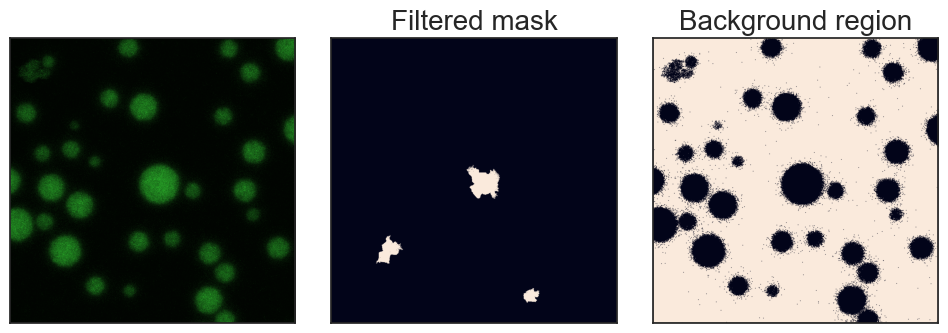

25bp_ASF1a600nM_Z-Series_1h_1.nd2
10
Chromatin 2.3007467744421803
329.8946826125482
143.38591551107646
label=4: lowest_ratio=0.9380724802825272 at z=3
label=100: lowest_ratio=0.949782935967504 at z=3
label=588: lowest_ratio=0.9337278687989412 at z=3
label=778: lowest_ratio=0.9094670290649539 at z=2
label=850: lowest_ratio=0.9228846320661985 at z=3
label=896: lowest_ratio=0.9080166400913252 at z=2
label=1225: lowest_ratio=0.9337453217717291 at z=4
label=1335: lowest_ratio=0.9193622110632009 at z=2
Protein 0.9268823898882975


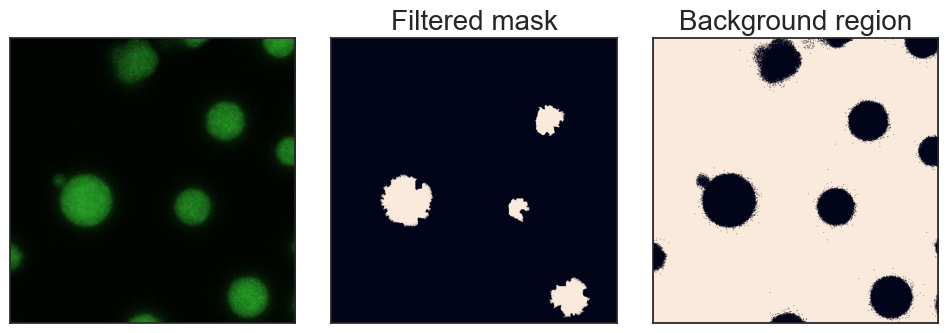

25bp_ASF1a600nM_Z-Series_zoom10_21h_1.nd2
21
Chromatin 2.14036014439261
354.9910140016823
165.85573924636006
label=2: lowest_ratio=0.8962906331871919 at z=3
label=5: lowest_ratio=0.8816779789196473 at z=5
label=7: lowest_ratio=0.915785974728291 at z=4
label=74: lowest_ratio=0.9295609946339263 at z=3
label=374: lowest_ratio=0.8991643796478129 at z=3
label=532: lowest_ratio=0.9222259621464979 at z=4
label=701: lowest_ratio=0.9217421060960307 at z=3
label=853: lowest_ratio=0.8766699843014387 at z=5
label=922: lowest_ratio=0.9390205882579438 at z=3
label=1383: lowest_ratio=0.9014236904100539 at z=4
label=1477: lowest_ratio=0.8917019325635156 at z=4
label=1666: lowest_ratio=0.9184989135325226 at z=4
label=1748: lowest_ratio=0.9315235045724218 at z=3
label=1754: lowest_ratio=0.931629697355558 at z=3
label=2149: lowest_ratio=0.918621285280354 at z=4
label=2226: lowest_ratio=0.8958329320889161 at z=4
label=2331: lowest_ratio=0.8860124071242363 at z=4
label=2405: lowest_ratio=0.9247863968601256

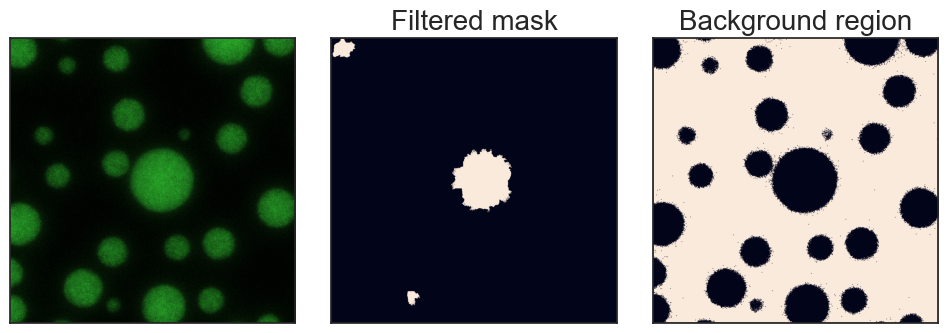

25bp_ASF1a600nM_Z-Series_zoom10_2h_1.nd2
8
Chromatin 2.3035690050220174
334.90056836795173
145.38334542522236
label=38: lowest_ratio=0.9134308934548908 at z=3
label=314: lowest_ratio=0.9187957121610841 at z=3
label=467: lowest_ratio=0.9090152480863454 at z=3
label=518: lowest_ratio=0.9109875445477909 at z=4
label=600: lowest_ratio=0.9161132321321451 at z=3
label=948: lowest_ratio=0.9107707730705064 at z=3
label=1113: lowest_ratio=0.9135653579874685 at z=3
Protein 0.9132398230628901


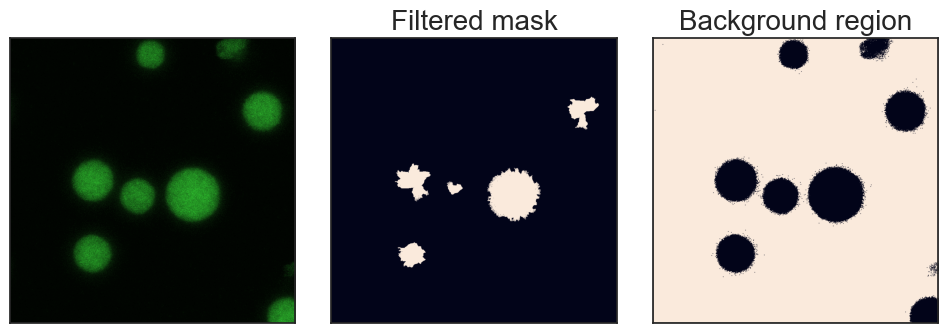

30bp_ASF1a600nM_Z-Series_0.5h_1.nd2
12
Chromatin 2.365811233234086
969.5821358188826
409.8307262213202
label=2: lowest_ratio=0.9477228354981676 at z=2
label=42: lowest_ratio=0.9567468410949397 at z=4
label=53: lowest_ratio=0.9684164571819571 at z=3
label=62: lowest_ratio=0.9444975982333862 at z=3
label=128: lowest_ratio=0.9551397129950496 at z=3
label=163: lowest_ratio=0.9657465789834653 at z=3
label=214: lowest_ratio=0.9692261303886462 at z=2
label=248: lowest_ratio=0.9556006357819349 at z=3
label=261: lowest_ratio=0.9516553806996203 at z=3
label=304: lowest_ratio=0.9656692631829873 at z=2
label=341: lowest_ratio=0.9659207205401047 at z=2
label=367: lowest_ratio=1.009847491187773 at z=1
Protein 0.9630158038140028


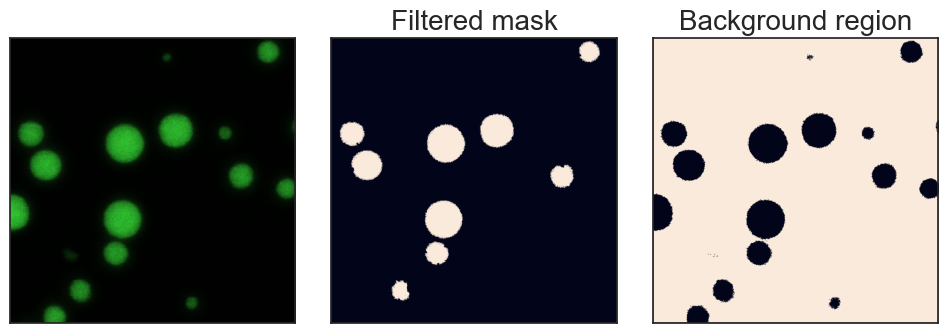

30bp_ASF1a600nM_Z-Series_1h_1.nd2
20
Chromatin 2.159480365776347
985.364320685162
456.2969575001981
label=1: lowest_ratio=0.9462195221768936 at z=4
label=6: lowest_ratio=0.9601904985432346 at z=3
label=41: lowest_ratio=0.9486189981035742 at z=5
label=59: lowest_ratio=0.946601288187935 at z=4
label=118: lowest_ratio=0.9677297294247392 at z=2
label=126: lowest_ratio=0.9564836145261205 at z=3
label=175: lowest_ratio=0.9744038040004122 at z=3
label=194: lowest_ratio=0.9539947331496418 at z=3
label=201: lowest_ratio=0.968305077530971 at z=3
label=213: lowest_ratio=0.9595312848346073 at z=3
label=223: lowest_ratio=0.9468048441743605 at z=4
label=347: lowest_ratio=0.9500066714706328 at z=3
label=350: lowest_ratio=0.9598682429801091 at z=5
label=370: lowest_ratio=0.9486975682540043 at z=5
label=456: lowest_ratio=0.9705777726595993 at z=4
label=481: lowest_ratio=0.9690341318307182 at z=4
label=499: lowest_ratio=0.9591108983860949 at z=4
label=548: lowest_ratio=0.9689768759254956 at z=3
label=56

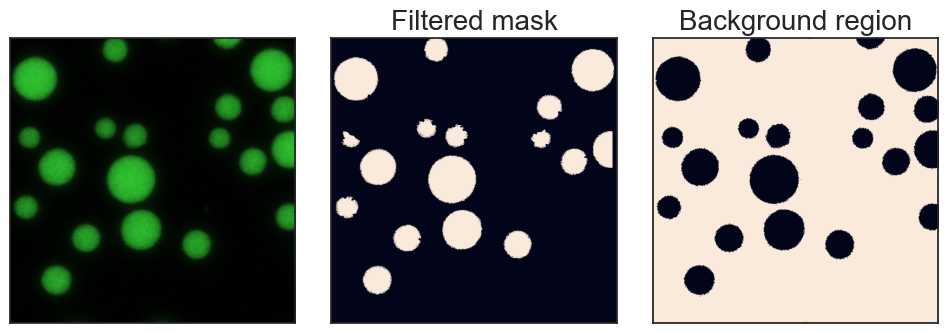

30bp_ASF1a600nM_Z-Series_zoom10_22h_1.nd2
15
Chromatin 2.2621677220376673
957.657369818525
423.3361481066076
label=1: lowest_ratio=0.950120239082393 at z=4
label=29: lowest_ratio=0.9380022788949863 at z=5
label=46: lowest_ratio=0.9547625107384378 at z=3
label=175: lowest_ratio=0.950124476756809 at z=4
label=186: lowest_ratio=0.9481186828839139 at z=5
label=259: lowest_ratio=0.936850213866898 at z=3
label=492: lowest_ratio=0.9471869806474426 at z=4
label=515: lowest_ratio=0.9576434578337237 at z=3
label=553: lowest_ratio=0.9437695562876333 at z=5
label=732: lowest_ratio=0.9457518904500192 at z=3
label=782: lowest_ratio=0.9561745919324214 at z=3
label=877: lowest_ratio=0.9477180883070598 at z=4
label=885: lowest_ratio=0.9654531075876137 at z=5
Protein 0.9493596980976424


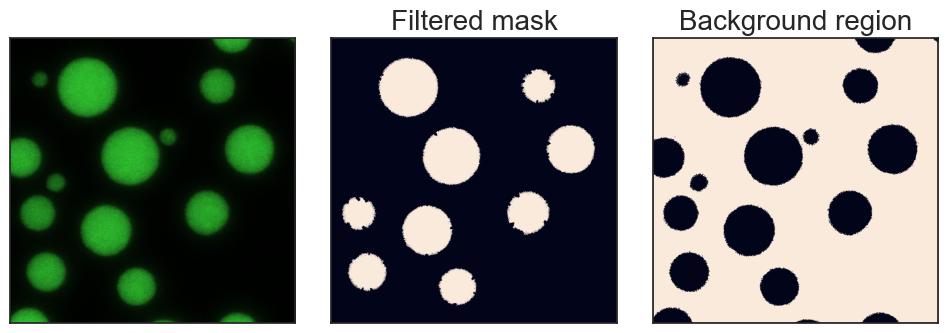

30bp_ASF1a600nM_Z-Series_zoom10_2h_1.nd2
24
Chromatin 2.199263393964985
990.3463163854378
450.3081891432625
label=1: lowest_ratio=0.9537681665930349 at z=3
label=3: lowest_ratio=0.9640897898152772 at z=2
label=24: lowest_ratio=0.9511576832522229 at z=2
label=79: lowest_ratio=0.9510397983367529 at z=4
label=88: lowest_ratio=0.9873152064862258 at z=2
label=140: lowest_ratio=0.9563648786924838 at z=4
label=145: lowest_ratio=0.963621108852017 at z=3
label=264: lowest_ratio=0.9465770094539452 at z=4
label=276: lowest_ratio=0.9505456224454694 at z=4
label=280: lowest_ratio=0.963616977052233 at z=3
label=325: lowest_ratio=0.9757036224037683 at z=5
label=454: lowest_ratio=0.9460561113853362 at z=3
label=523: lowest_ratio=0.952485475565638 at z=4
label=587: lowest_ratio=0.9475728618362063 at z=4
label=622: lowest_ratio=0.9746135947124379 at z=4
label=651: lowest_ratio=0.9614563363046954 at z=4
label=838: lowest_ratio=0.9708722913013996 at z=2
label=861: lowest_ratio=0.9531895265818435 at z=2
la

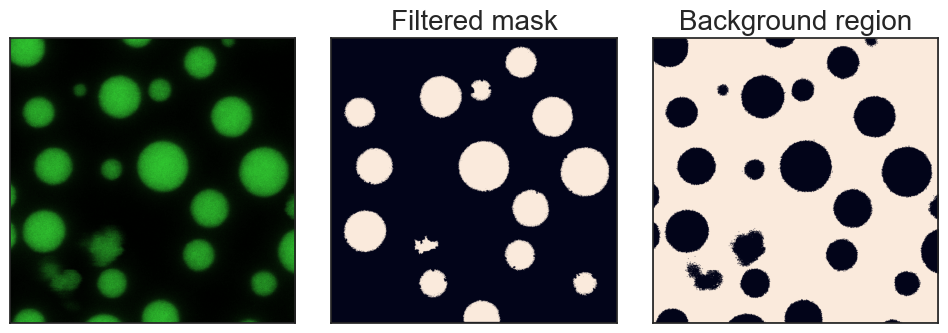

                                    Filename  Concentration  Time BasePairs  \
0        25bp_ASF1a600nM_Z-Series_0.5h_1.nd2            600   0.5        25   
1          25bp_ASF1a600nM_Z-Series_1h_1.nd2            600   1.0        25   
2  25bp_ASF1a600nM_Z-Series_zoom10_21h_1.nd2            600  21.0        25   
3   25bp_ASF1a600nM_Z-Series_zoom10_2h_1.nd2            600   2.0        25   
4        30bp_ASF1a600nM_Z-Series_0.5h_1.nd2            600   0.5        30   
5          30bp_ASF1a600nM_Z-Series_1h_1.nd2            600   1.0        30   
6  30bp_ASF1a600nM_Z-Series_zoom10_22h_1.nd2            600  22.0        30   
7   30bp_ASF1a600nM_Z-Series_zoom10_2h_1.nd2            600   2.0        30   

    Protein  Chromatin       Area       Condition  
0  0.911533   2.596223   3.937645  25bp0.5h,600nM  
1  0.926882   2.300747   9.387058    25bp1h,600nM  
2  0.911304   2.140360  10.174948   25bp21h,600nM  
3  0.913240   2.303569   7.573860    25bp2h,600nM  
4  0.963016   2.365811   6.3

In [10]:
im_folder1 = "D:/LLPS/20260512/zoom10/ASF1a/"
df_ASF1a, bp25_ASF1a, bp30_ASF1a, unique_time_ASF1a = extract_info(im_folder1, 'ASF1a')

In [ ]:
im_folder2 = "D:/LLPS/20260512/zoom10/ASF1b/"
df_ASF1b, bp25_ASF1b, bp30_ASF1b, unique_time_ASF1b = extract_info(im_folder2, 'ASF1b')


In [ ]:
im_folder3 = "D:/LLPS/20260512/zoom10/ctr/"
df_control, bp25_control, bp30_control, unique_time_control = extract_info(im_folder3, 'control')
    

## For Protein Concentration Titration

In [ ]:
# Protein Intensity changes
def plot_proteinIntsy(bp25, bp30, unique_time):
    fig, ax = plt.subplots()

    colors_bp25 = plt.cm.PuBu(np.linspace(0.3, 0.9, len(unique_time))) 
    colors_bp30 = plt.cm.RdPu(np.linspace(0.3, 0.8, len(unique_time))) 

    i=0
    for t in unique_time:
        bp25_h = bp25[bp25["Time"]==t]
        # Computes mean and standard deviation
        bp25_grouped = bp25_h.groupby("Condition").agg({"Protein": ["mean", "std"]}).reset_index()
        # Rename columns for clarity
        bp25_grouped.columns = ["Condition", "Protein_Mean", "Protein_Std"]
        bp25_grouped["Concentration"] = pd.to_numeric(bp25_grouped["Condition"].str.extract(r'(\d+)nM')[0])
        
        # print(bp25_grouped)
        
        bp30_h = bp30[bp30['Time']==t]
        bp30_grouped = bp30_h.groupby("Condition").agg({"Protein": ["mean", "std"]}).reset_index()
        # Rename columns for clarity
        bp30_grouped.columns = ["Condition", "Protein_Mean", "Protein_Std"]
        bp30_grouped["Concentration"] = pd.to_numeric(bp30_grouped["Condition"].str.extract(r'(\d+)nM')[0])

        bp25_grouped = bp25_grouped.sort_values(by="Concentration")
        bp30_grouped = bp30_grouped.sort_values(by="Concentration")
        # bp25_h["Condition"].str.extract(r'([a-zA-Z0-9.-]+),')
        # ax.plot(bp25_h['Concentration'], bp25_h['Protein'], c=colors_bp25[i], linewidth = 3, label = f"\n25bp{t}hs")
        # ax.plot(bp30_h['Concentration'], bp30_h['Protein'], c=colors_bp30[i], linewidth = 3, label = f"\n30bp{t}hs")

        # ax.plot(bp25_grouped['Concentration'], bp25_grouped['Protein_Mean'], c=colors_bp25[i], linewidth = 3, label = f"\n25bp{t}hs")
        # ax.plot(bp30_grouped['Concentration'], bp30_grouped['Protein_Mean'], c=colors_bp30[i], linewidth = 3, label = f"\n30bp{t}hs")
        
        # Plot line with standard deviation as error bars (vertical shortlines)
        ax.errorbar(bp25_grouped['Concentration'], bp25_grouped['Protein_Mean'], yerr=bp25_grouped['Protein_Std'],
                    fmt='o', color=colors_bp25[i], linewidth = 4, capsize=6, linestyle="-", label=f"\n25bp{t}hs")
        ax.errorbar(bp30_grouped['Concentration'], bp30_grouped['Protein_Mean'], yerr=bp30_grouped['Protein_Std'], 
                    fmt='o', color=colors_bp30[i], linewidth = 4, capsize=6, linestyle="-", label=f"\n30bp{t}hs")

        i+=1

    ax.set_xticks(np.arange(min(bp30_grouped['Concentration']), max(bp30_grouped['Concentration']) + 1, 600))
    ax.set_xticks(np.arange(0, max(bp30_grouped['Concentration']) + 1, 600))
    ax.legend(fontsize='xx-small', loc=1, bbox_to_anchor=(1.4, 1))
    plt.xlabel("[ASF1a](nM) ")
    plt.ylabel("ASF1a FI")
    plt.title('ASF1a Intensity')
    # plt.tight_layout()

    plt.show()

# plot chromatin intensity changes
def plot_chromatinIntsy(bp25, bp30, unique_time):
    fig, ax = plt.subplots()

    colors_bp25 = plt.cm.PuBu(np.linspace(0.3, 0.9, len(unique_time))) 
    colors_bp30 = plt.cm.YlGn(np.linspace(0.3, 0.8, len(unique_time))) 

    i=0
    for t in unique_time:
        bp25_h = bp25[bp25["Time"]==t]
        # Computes mean and standard deviation
        bp25_grouped = bp25_h.groupby("Condition").agg({"Chromatin": ["mean", "std"]}).reset_index()
        # Rename columns for clarity
        bp25_grouped.columns = ["Condition", "Chromatin_Mean", "Chromatin_Std"]
        bp25_grouped["Concentration"] = pd.to_numeric(bp25_grouped["Condition"].str.extract(r'(\d+)nM')[0])
        
        # print(bp25_grouped)
        
        bp30_h = bp30[bp30['Time']==t]
        bp30_grouped = bp30_h.groupby("Condition").agg({"Chromatin": ["mean", "std"]}).reset_index()
        # Rename columns for clarity
        bp30_grouped.columns = ["Condition", "Chromatin_Mean", "Chromatin_Std"]
        bp30_grouped["Concentration"] = pd.to_numeric(bp30_grouped["Condition"].str.extract(r'(\d+)nM')[0])

        bp25_grouped = bp25_grouped.sort_values(by="Concentration")
        bp30_grouped = bp30_grouped.sort_values(by="Concentration")
        # bp25_h["Condition"].str.extract(r'([a-zA-Z0-9.-]+),')
        # ax.plot(bp25_h['Concentration'], bp25_h['Protein'], c=colors_bp25[i], linewidth = 3, label = f"\n25bp{t}hs")
        # ax.plot(bp30_h['Concentration'], bp30_h['Protein'], c=colors_bp30[i], linewidth = 3, label = f"\n30bp{t}hs")

        # ax.plot(bp25_grouped['Concentration'], bp25_grouped['Protein_Mean'], c=colors_bp25[i], linewidth = 3, label = f"\n25bp{t}hs")
        # ax.plot(bp30_grouped['Concentration'], bp30_grouped['Protein_Mean'], c=colors_bp30[i], linewidth = 3, label = f"\n30bp{t}hs")
        
        # Plot line with standard deviation as error bars (vertical shortlines)
        ax.errorbar(bp25_grouped['Concentration'], bp25_grouped['Chromatin_Mean'], yerr=bp25_grouped['Chromatin_Std'], 
                    fmt='o', color=colors_bp25[i], linewidth = 4, capsize=6, linestyle="-", label=f"\n25bp{t}hs")
        ax.errorbar(bp30_grouped['Concentration'], bp30_grouped['Chromatin_Mean'], yerr=bp30_grouped['Chromatin_Std'], 
                    fmt='o', color=colors_bp30[i], linewidth = 4, capsize=6, linestyle="-", label=f"\n30bp{t}hs")

        i+=1

    # ax.set_xticks(np.arange(min(bp30_grouped['Concentration']), max(bp30_grouped['Concentration']) + 1, 600))
    ax.set_xticks(np.arange(0, max(bp30_grouped['Concentration']) + 1, 600))
    ax.legend(fontsize='xx-small', loc=1, bbox_to_anchor=(1.4, 1))
    plt.xlabel("[ASF1a](nM) ")
    plt.ylabel("Chromatin FI")
    plt.title('Chromatin Condensates Intensity')
    # plt.tight_layout()

    plt.show()


# plot chromatin size changes
def plot_chromatinSz(bp25, bp30, unique_time):
    fig, ax = plt.subplots()

    colors_bp25 = plt.cm.PuBu(np.linspace(0.3, 0.9, len(unique_time))) 
    colors_bp30 = plt.cm.OrRd(np.linspace(0.3, 0.8, len(unique_time))) 

    i=0
    for t in unique_time:
        bp25_h = bp25[bp25["Time"]==t]
        # Computes mean and standard deviation
        bp25_grouped = bp25_h.groupby("Condition").agg({"Area": ["mean", "std"]}).reset_index()
        # Rename columns for clarity
        bp25_grouped.columns = ["Condition", "Area_Mean", "Area_Std"]
        bp25_grouped["Concentration"] = pd.to_numeric(bp25_grouped["Condition"].str.extract(r'(\d+)nM')[0])
        
        # print(bp25_grouped)
        
        bp30_h = bp30[bp30['Time']==t]
        bp30_grouped = bp30_h.groupby("Condition").agg({"Area": ["mean", "std"]}).reset_index()
        # Rename columns for clarity
        bp30_grouped.columns = ["Condition", "Area_Mean", "Area_Std"]
        bp30_grouped["Concentration"] = pd.to_numeric(bp30_grouped["Condition"].str.extract(r'(\d+)nM')[0])

        bp25_grouped = bp25_grouped.sort_values(by="Concentration")
        bp30_grouped = bp30_grouped.sort_values(by="Concentration")

        ax.errorbar(bp25_grouped['Concentration'], bp25_grouped['Area_Mean'], yerr=bp25_grouped['Area_Std'], 
                    fmt='o', color=colors_bp25[i], linewidth = 4, capsize=6, linestyle="-", label=f"\n25bp{t}hs")
        ax.errorbar(bp30_grouped['Concentration'], bp30_grouped['Area_Mean'], yerr=bp30_grouped['Area_Std'], 
                    fmt='o', color=colors_bp30[i], linewidth = 4, capsize=6, linestyle="-", label=f"\n30bp{t}hs")

        i+=1

    # ax.set_xticks(np.arange(min(bp30_grouped['Concentration']), max(bp30_grouped['Concentration']) + 1, 600))
    ax.set_xticks(np.arange(0, max(bp30_grouped['Concentration']) + 1, 600))
    ax.legend(fontsize='xx-small', loc=1, bbox_to_anchor=(1.4, 1))
    plt.xlabel("[ASF1a](nM) ")
    plt.ylabel("Condensates Area(um^2)")
    plt.title('Chromatin Condensates Size')
    # plt.tight_layout()

    plt.show()

def plot_concentration_titrat(bp25, bp30, unique_time):
    plot_proteinIntsy(bp25, bp30, unique_time)
    plot_chromatinIntsy(bp25, bp30, unique_time)
    plot_chromatinSz(bp25, bp30, unique_time)
    

## For Time points

### compare between 25bp and 30bp

In [ ]:
# Protein Intensity changes
def plot_proteinIntsy(bp25, bp30, figsize):
    fig, ax = plt.subplots(figsize=figsize)

    # colors_bp25 = plt.cm.PuBu(np.linspace(0.3, 0.9, len(unique_time))) 
    # colors_bp30 = plt.cm.RdPu(np.linspace(0.3, 0.8, len(unique_time))) 

    bp25_grouped = bp25.groupby("Time").agg({"Protein": ["mean", "std"]}).reset_index()
    bp25_grouped.columns = ["Time", "Protein_Mean", "Protein_Std"]

    bp30_grouped = bp30.groupby("Time").agg({"Protein": ["mean", "std"]}).reset_index()
    bp30_grouped.columns = ["Time", "Protein_Mean", "Protein_Std"]

    ax.errorbar(bp25_grouped['Time'], bp25_grouped['Protein_Mean'], yerr=bp25_grouped['Protein_Std'],
                    fmt='o', color='plum', linewidth = 4, capsize=6, linestyle="-", label="25bp")
    ax.errorbar(bp30_grouped['Time'], bp30_grouped['Protein_Mean'], yerr=bp30_grouped['Protein_Std'], 
                    fmt='o', color='mediumvioletred', linewidth = 4, capsize=6, linestyle="-", label="30bp")

    # ax.set_xticks(np.arange(min(df_ASF1a['Time']), max(df_ASF1a['Time']) + 1, 600))
    ax.set_xticks(np.arange(0, max(bp25['Time']) + 1, 1))
    ax.legend(fontsize='xx-small', loc=1, bbox_to_anchor=(1.2, 1))
    ax.tick_params(
        axis='both',        # x and y    
        direction='in',     # 'in', 'out', or 'inout'
        labelsize=12, top=False, right=False, left=True, bottom=True) 
    plt.xlabel("Time(h)")
    plt.ylabel("Protein FI")
    plt.title('Protein Intensity')
    # plt.tight_layout()
    return fig, ax


# plot chromatin intensity changes
def plot_chromatinIntsy(bp25, bp30, figsize):
    fig, ax = plt.subplots(figsize=figsize)

    # colors_bp25 = plt.cm.PuBu(np.linspace(0.3, 0.9, len(unique_time))) 
    # colors_bp30 = plt.cm.YlGn(np.linspace(0.3, 0.8, len(unique_time))) 

    bp25_grouped = bp25.groupby("Time").agg({"Chromatin": ["mean", "std"]}).reset_index()
        # Rename columns for clarity
    bp25_grouped.columns = ["Time", "Chromatin_Mean", "Chromatin_Std"]
    bp30_grouped = bp30.groupby("Time").agg({"Chromatin": ["mean", "std"]}).reset_index()
        # Rename columns for clarity
    bp30_grouped.columns = ["Time", "Chromatin_Mean", "Chromatin_Std"]
        
    ax.errorbar(bp25_grouped['Time'], bp25_grouped['Chromatin_Mean'], yerr=bp25_grouped['Chromatin_Std'], 
                    fmt='o', color='greenyellow', linewidth = 4, capsize=6, linestyle="-", label="25bp")
    ax.errorbar(bp30_grouped['Time'], bp30_grouped['Chromatin_Mean'], yerr=bp30_grouped['Chromatin_Std'], 
                    fmt='o', color='forestgreen', linewidth = 4, capsize=6, linestyle="-", label="30bp")


    # ax.set_xticks(np.arange(min(bp30_grouped['Concentration']), max(bp30_grouped['Concentration']) + 1, 600))
    ax.set_xticks(np.arange(0, max(bp30_grouped['Time']) + 1, 1))
    ax.tick_params(
        axis='both',        # x and y    
        direction='in',     # 'in', 'out', or 'inout'
        labelsize=12, top=False, right=False, left=True, bottom=True) 
    ax.legend(fontsize='xx-small', loc=1, bbox_to_anchor=(1.2, 1))
    plt.xlabel("Time(h)")
    plt.ylabel("Chromatin FI")
    plt.title('Chromatin Condensates Intensity')
    # plt.tight_layout()
    return fig, ax



# plot chromatin size changes
def plot_chromatinSz(bp25, bp30, figsize):
    fig, ax = plt.subplots(figsize=figsize)

    # Computes mean and standard deviation
    bp25_grouped = bp25.groupby("Time").agg({"Area": ["mean", "std"]}).reset_index()
    # Rename columns for clarity
    bp25_grouped.columns = ["Time", "Area_Mean", "Area_Std"]
    
    # print(bp25_grouped)
    
    bp30_grouped = bp30.groupby("Time").agg({"Area": ["mean", "std"]}).reset_index()
    # Rename columns for clarity
    bp30_grouped.columns = ["Time", "Area_Mean", "Area_Std"]

    ax.errorbar(bp25_grouped['Time'], bp25_grouped['Area_Mean'], yerr=bp25_grouped['Area_Std'], 
                fmt='o', color='lightcoral', linewidth = 4, capsize=6, linestyle="-", label="25bp")
    ax.errorbar(bp30_grouped['Time'], bp30_grouped['Area_Mean'], yerr=bp30_grouped['Area_Std'], 
                fmt='o', color='firebrick', linewidth = 4, capsize=6, linestyle="-", label="30bp")


    # ax.set_xticks(np.arange(min(bp30_grouped['Concentration']), max(bp30_grouped['Concentration']) + 1, 600))
    ax.set_xticks(np.arange(0, max(bp30_grouped['Time']) + 1, 1))
    ax.tick_params(
        axis='both',        # x and y    
        direction='in',     # 'in', 'out', or 'inout'
        labelsize=12, top=False, right=False, left=True, bottom=True) 
    ax.legend(fontsize='xx-small', loc=1, bbox_to_anchor=(1.2, 1))
    plt.xlabel("Time(h)")
    plt.ylabel("Condensates Area(um^2)")
    plt.title('Chromatin Condensates Size')
    # plt.tight_layout()
    return fig, ax


def plot_time_point(bp25, bp30, figsize=(9, 5)):
    # fig = plt.figure(figsize=(15,5))
    fig1, ax1 = plot_proteinIntsy(bp25, bp30, figsize)
    fig2, ax2 = plot_chromatinIntsy(bp25, bp30, figsize)
    fig3, ax3 = plot_chromatinSz(bp25, bp30, figsize)
    plt.show()
    

In [ ]:
# plot_time_point(bp25_ASF1a, bp30_ASF1a)
plot_time_point(bp25_ASF1b, bp30_ASF1b)

### compare between two proteins and 25bp and 30bp

In [ ]:
# Protein Intensity changes
def plot_proteinIntsy(bp25, bp30, color, prot, ax):
    # fig, ax = plt.subplots(figsize = figsize)
    colors_bp25 = plt.cm.PuBu(np.linspace(0.3, 0.9, 2)) 
    colors_bp30 = plt.cm.RdPu(np.linspace(0.3, 0.8, 2)) 

    bp25_grouped = bp25.groupby("Time").agg({"Protein": ["mean", "std"]}).reset_index()
    bp25_grouped.columns = ["Time", "Protein_Mean", "Protein_Std"]

    bp30_grouped = bp30.groupby("Time").agg({"Protein": ["mean", "std"]}).reset_index()
    bp30_grouped.columns = ["Time", "Protein_Mean", "Protein_Std"]

    ax.errorbar(bp25_grouped['Time'], bp25_grouped['Protein_Mean'], yerr=bp25_grouped['Protein_Std'],
                    fmt='o', color=colors_bp25[color], linewidth = 4, capsize=6, linestyle="-", label="25bp"+prot)
    ax.errorbar(bp30_grouped['Time'], bp30_grouped['Protein_Mean'], yerr=bp30_grouped['Protein_Std'], 
                    fmt='o', color=colors_bp30[color], linewidth = 4, capsize=6, linestyle="-", label="30bp"+prot)

    # ax.set_xticks(np.arange(min(df_ASF1a['Time']), max(df_ASF1a['Time']) + 1, 600))
    ax.set_xticks(np.arange(0, max(bp25['Time']) + 1, 1))
    ax.legend(fontsize='xx-small', loc=1, bbox_to_anchor=(1.3, 1))
    ax.tick_params(
        axis='both',        # x and y    
        direction='in',     # 'in', 'out', or 'inout'
        labelsize=12, top=False, right=False, left=True, bottom=True) 
    plt.xlabel("Time(h)")
    plt.ylabel("Protein FI")
    plt.title('Protein Intensity')
    # plt.tight_layout()
    # return fig, ax


# plot chromatin intensity changes
def plot_chromatinIntsy(bp25, bp30, color, prot, ax):
    # fig, ax = plt.subplots(figsize=figsize)

    colors_bp25 = plt.cm.PuBu(np.linspace(0.3, 0.9, 2)) 
    colors_bp30 = plt.cm.YlGn(np.linspace(0.3, 0.8, 2)) 

    bp25_grouped = bp25.groupby("Time").agg({"Chromatin": ["mean", "std"]}).reset_index()
        # Rename columns for clarity
    bp25_grouped.columns = ["Time", "Chromatin_Mean", "Chromatin_Std"]
    bp30_grouped = bp30.groupby("Time").agg({"Chromatin": ["mean", "std"]}).reset_index()
        # Rename columns for clarity
    bp30_grouped.columns = ["Time", "Chromatin_Mean", "Chromatin_Std"]
        
    ax.errorbar(bp25_grouped['Time'], bp25_grouped['Chromatin_Mean'], yerr=bp25_grouped['Chromatin_Std'], 
                    fmt='o', color=colors_bp25[color], linewidth = 4, capsize=6, linestyle="-", label="25bp"+prot)
    ax.errorbar(bp30_grouped['Time'], bp30_grouped['Chromatin_Mean'], yerr=bp30_grouped['Chromatin_Std'], 
                    fmt='o', color=colors_bp30[color], linewidth = 4, capsize=6, linestyle="-", label="30bp"+prot)


    # ax.set_xticks(np.arange(min(bp30_grouped['Concentration']), max(bp30_grouped['Concentration']) + 1, 600))
    ax.set_xticks(np.arange(0, max(bp30_grouped['Time']) + 1, 1))
    ax.tick_params(
        axis='both',        # x and y    
        direction='in',     # 'in', 'out', or 'inout'
        labelsize=12, top=False, right=False, left=True, bottom=True) 
    ax.legend(fontsize='xx-small', loc=1, bbox_to_anchor=(1.3, 1))
    plt.xlabel("Time(h)")
    plt.ylabel("Chromatin FI")
    plt.title('Chromatin Condensates Intensity')
    # plt.tight_layout()
    # return fig, ax



# plot chromatin size changes
def plot_chromatinSz(bp25, bp30, color, prot, ax):
    # fig, ax = plt.subplots(figsize=figsize)

    colors_bp25 = plt.cm.PuBu(np.linspace(0.3, 0.9, 2)) 
    colors_bp30 = plt.cm.OrRd(np.linspace(0.3, 0.8, 2)) 

    # Computes mean and standard deviation
    bp25_grouped = bp25.groupby("Time").agg({"Area": ["mean", "std"]}).reset_index()
    # Rename columns for clarity
    bp25_grouped.columns = ["Time", "Area_Mean", "Area_Std"]
    
    # print(bp25_grouped)
    
    bp30_grouped = bp30.groupby("Time").agg({"Area": ["mean", "std"]}).reset_index()
    # Rename columns for clarity
    bp30_grouped.columns = ["Time", "Area_Mean", "Area_Std"]

    ax.errorbar(bp25_grouped['Time'], bp25_grouped['Area_Mean'], yerr=bp25_grouped['Area_Std'], 
                fmt='o', color=colors_bp25[color], linewidth = 4, capsize=6, linestyle="-", label="25bp"+prot)
    ax.errorbar(bp30_grouped['Time'], bp30_grouped['Area_Mean'], yerr=bp30_grouped['Area_Std'], 
                fmt='o', color=colors_bp30[color]   , linewidth = 4, capsize=6, linestyle="-", label="30bp"+prot)


    # ax.set_xticks(np.arange(min(bp30_grouped['Concentration']), max(bp30_grouped['Concentration']) + 1, 600))
    ax.set_xticks(np.arange(0, max(bp30_grouped['Time']) + 1, 1))
    ax.tick_params(
        axis='both',        # x and y    
        direction='in',     # 'in', 'out', or 'inout'
        labelsize=12, top=False, right=False, left=True, bottom=True) 
    ax.legend(fontsize='xx-small', loc=1, bbox_to_anchor=(1.3, 1))
    plt.xlabel("Time(h)")
    plt.ylabel("Condensates Area(um^2)")
    plt.title('Chromatin Condensates Size')
    # plt.tight_layout()
    # return fig, ax

    

In [ ]:
# def plot_time_point(bp25, bp30, figsize=(9, 5)):
    # fig = plt.figure(figsize=(15,5))
proteins=['ASF1a', 'ASF1b']

fig, ax = plt.subplots(figsize=(9, 5))
for prot in proteins:
    plot_proteinIntsy(globals()[f'bp25_{prot}'], globals()[f'bp30_{prot}'], color = globals()[f'proteins'].index(prot), prot =prot, ax=ax)
plt.show()
    
fig, ax = plt.subplots(figsize=(9, 5))
for prot in proteins:
    plot_chromatinIntsy(globals()[f'bp25_{prot}'], globals()[f'bp30_{prot}'], color = globals()[f'proteins'].index(prot), prot =prot, ax=ax)
plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
for prot in proteins:
    plot_chromatinSz(globals()[f'bp25_{prot}'], globals()[f'bp30_{prot}'], color = globals()[f'proteins'].index(prot), prot =prot, ax=ax)
plt.show()